In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import salem
import pandas as pd
plt.style.use('bmh')

In [2]:
clim_dir = '/home/chc-shrad/DATA/SIF/climatology/fusion_SCIAMACHY_GOME-2'

for month in range(1, 13):
    out_mean_file = f'{clim_dir}/SIF_SCIAMACHY_GOME2_Harmonized.sif005_mean_month_{month:02d}.nc4'
    out_std_file = f'{clim_dir}/SIF_SCIAMACHY_GOME2_Harmonized.sif005_std_month_{month:02d}.nc4'
    sif_data = xr.open_mfdataset(f'/home/chc-shrad/DATA/SIF/fusion_SCIAMACHY_GOME-2/SIF_SCIAMACHY_GOME2_Harmonized.sif005_????{month:02d}_subsetted.nc4', 
                                 combine='nested', concat_dim='time', parallel=True)
    sif_mean = sif_data.mean(dim='time')
    sif_std = sif_data.std(dim='time')
    print (f'Writing mean and std for month {month:02d} to {out_mean_file} and {out_std_file}')
    sif_mean.to_netcdf(out_mean_file)
    sif_std.to_netcdf(out_std_file)

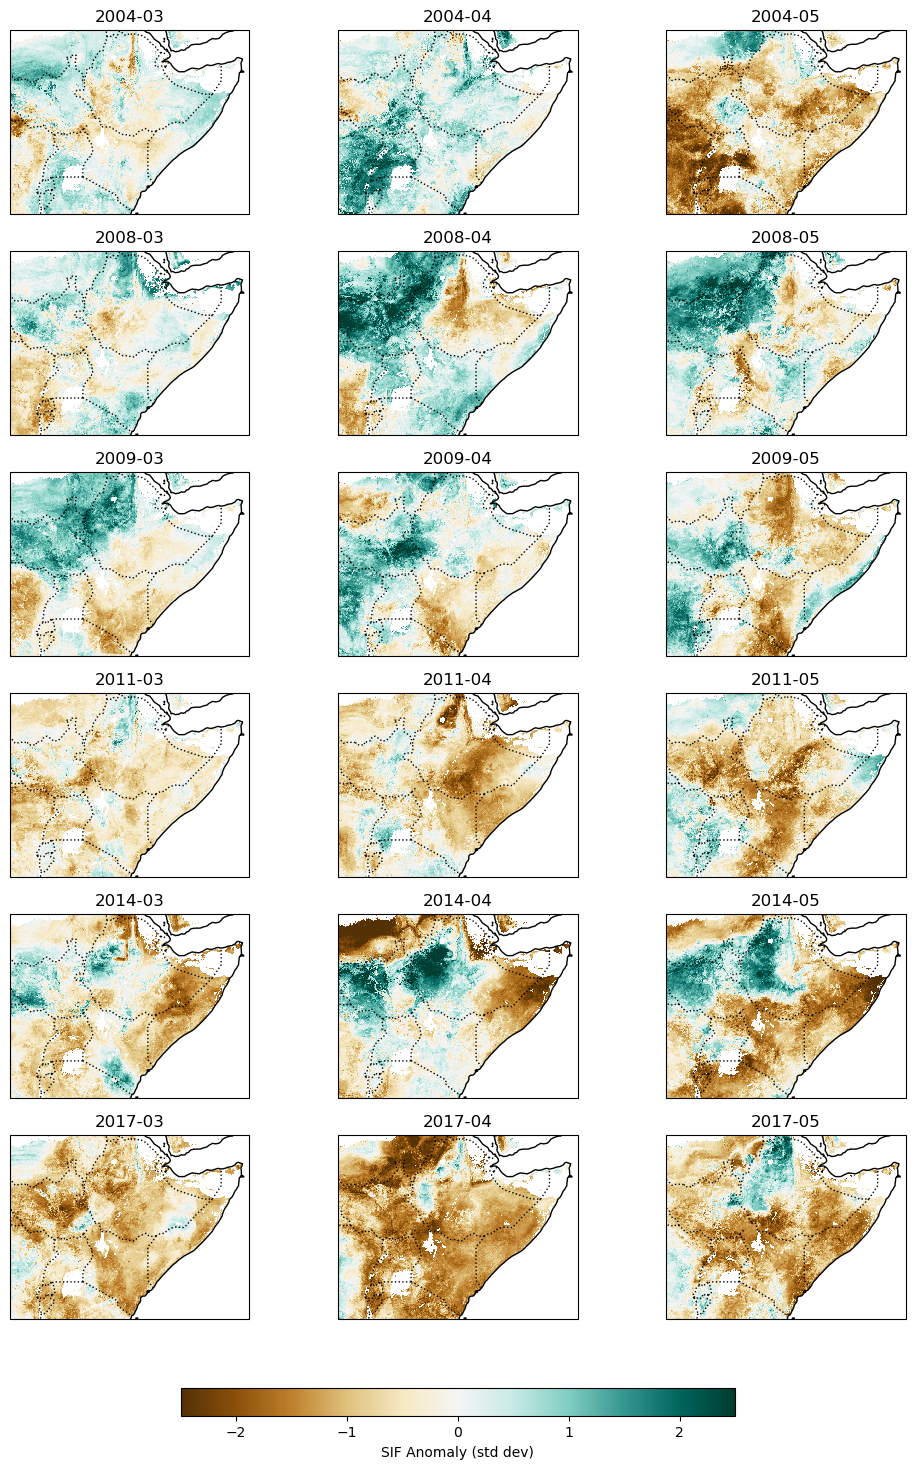

In [31]:
year_list = [2004, 2008, 2009, 2011, 2014, 2017]
smon, emon = 3, 5
nrows, ncols = len(year_list), emon - smon + 1
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*3), subplot_kw={'projection': ccrs.PlateCarree()})
for year in year_list:
    for month in range(smon, emon+1):
        ax = axes[year_list.index(year), month-smon]
        sif_rt = xr.open_dataset(f'/home/chc-shrad/DATA/SIF/fusion_SCIAMACHY_GOME-2/SIF_SCIAMACHY_GOME2_Harmonized.sif005_{year}{month:02d}_subsetted.nc4')
        sif_mean = xr.open_dataset(f'{clim_dir}/SIF_SCIAMACHY_GOME2_Harmonized.sif005_mean_month_{month:02d}.nc4')
        sif_std = xr.open_dataset(f'{clim_dir}/SIF_SCIAMACHY_GOME2_Harmonized.sif005_std_month_{month:02d}.nc4')
        sif_rt_anom = (sif_rt['SIF_740_daily_corr'] - sif_mean['SIF_740_daily_corr']) / sif_std['SIF_740_daily_corr']
        sel_sif_rt_anom = sif_rt_anom.sel(lat=slice(-5, 15), lon=slice(26, 52))
        im = ax.pcolormesh(sel_sif_rt_anom['lon'], sel_sif_rt_anom['lat'], sel_sif_rt_anom, cmap='BrBG', vmin=-2.5, vmax=2.5)
        ax.set_title(f'{year}-{month:02d}')
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':')
fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.02, pad=0.05, label='SIF Standardized Anomaly')


Processing year 2015, month 11
Processing year 2014, month 12
Processing year 2015, month 01
Processing year 2015, month 02
Processing year 2015, month 03
Processing year 2016, month 11
Processing year 2015, month 12
Processing year 2016, month 01
Processing year 2016, month 02
Processing year 2016, month 03
Processing year 2017, month 11
Processing year 2016, month 12
Processing year 2017, month 01
Processing year 2017, month 02
Processing year 2017, month 03


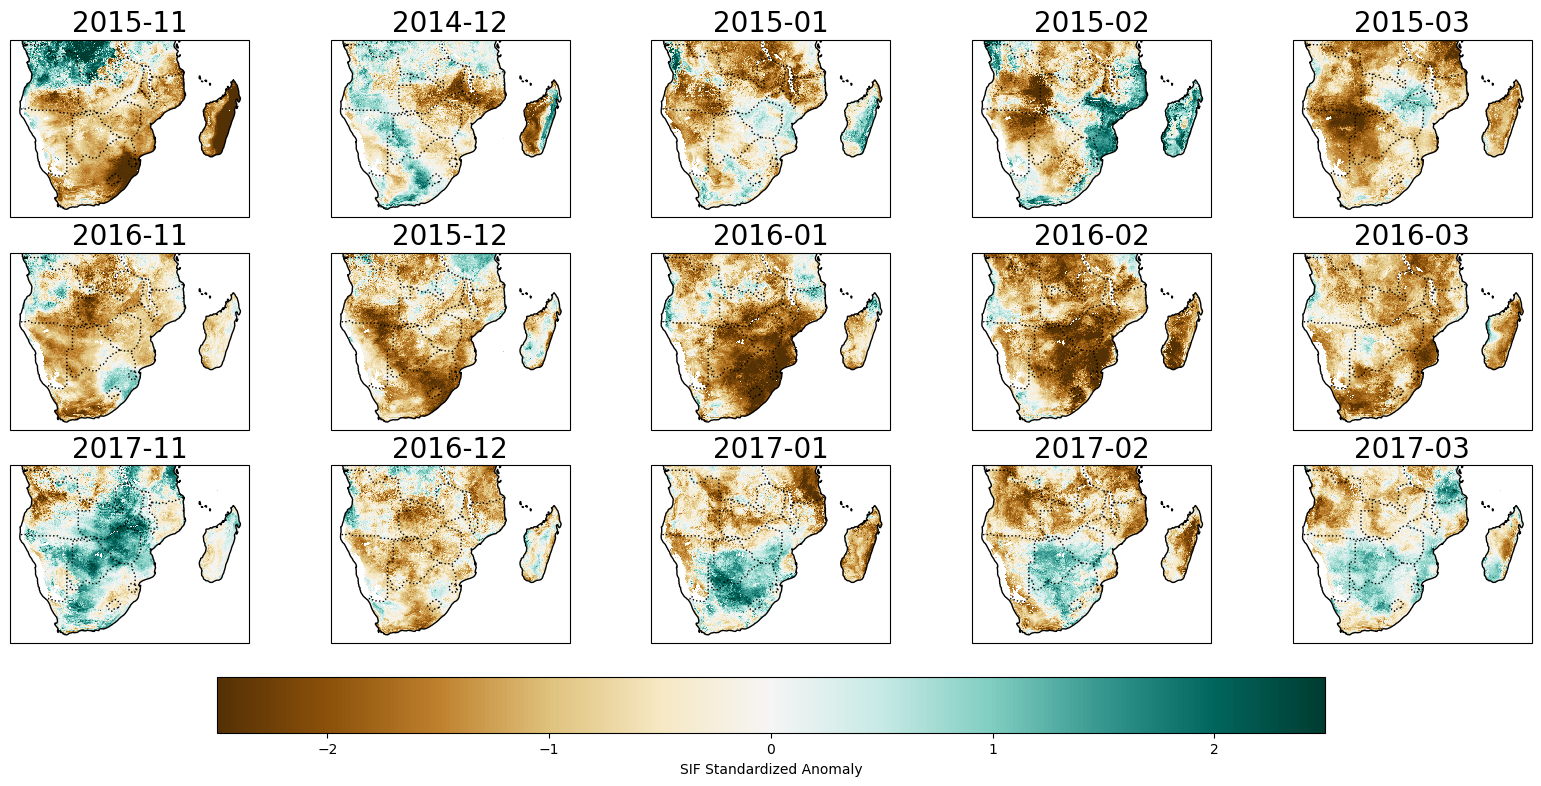

In [43]:
year_list = [2014, 2015, 2016]
smon, emon = 11, 3
nrows, ncols = len(year_list), (emon - smon + 12) % 12 + 1
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*3), subplot_kw={'projection': ccrs.PlateCarree()})
for year in year_list:
    for month in [11, 12, 1, 2, 3]:
        ax = axes[year_list.index(year), (month-smon) % 12]
        if month <12:
            year_to_use = year + 1
        else:
            year_to_use = year

        print (f'Processing year {year_to_use}, month {month:02d}')
        sif_rt = xr.open_dataset(f'/home/chc-shrad/DATA/SIF/fusion_SCIAMACHY_GOME-2/SIF_SCIAMACHY_GOME2_Harmonized.sif005_{year_to_use}{month:02d}_subsetted.nc4')
        sif_mean = xr.open_dataset(f'{clim_dir}/SIF_SCIAMACHY_GOME2_Harmonized.sif005_mean_month_{month:02d}.nc4')
        sif_std = xr.open_dataset(f'{clim_dir}/SIF_SCIAMACHY_GOME2_Harmonized.sif005_std_month_{month:02d}.nc4')
        sif_rt_anom = (sif_rt['SIF_740_daily_corr'] - sif_mean['SIF_740_daily_corr']) / sif_std['SIF_740_daily_corr']
        sel_sif_rt_anom = sif_rt_anom.sel(lat=slice(-37, -5), lon=slice(10, 52))
        im = ax.pcolormesh(sel_sif_rt_anom['lon'], sel_sif_rt_anom['lat'], sel_sif_rt_anom, cmap='BrBG', vmin=-2.5, vmax=2.5)
        ax.set_title(f'{year_to_use}-{month:02d}', fontsize=20)
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':')
fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.08, pad=0.05, label='SIF Standardized Anomaly')


In [3]:
date_range = pd.date_range(start='2003-01-01', end='2017-12-31', freq='ME')
crop_mask = xr.open_dataset('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_masks/lu_et_al/Global-cropland-percentage-map.nc')
admin_shp = gpd.read_file('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/Harvest_stat/hvstat_boundary.gpkg')
sif_data = xr.open_mfdataset(f'/home/chc-shrad/DATA/SIF/fusion_SCIAMACHY_GOME-2/SIF_SCIAMACHY_GOME2_Harmonized.*_subsetted.nc4', 
                             concat_dim='time', combine='nested')
sif_data.coords['time'] = date_range

In [5]:
crop_mask_africa = crop_mask['crop_mask'].sel(latitude=slice(37, -37), longitude=slice(-25, 52))
crop_mask_africa = crop_mask_africa.sortby('latitude', ascending=True)
crop_mask_regrid = crop_mask_africa.interp(latitude=sif_data['lat'].values, longitude=sif_data['lon'].values, method='nearest')
crop_mask_regrid = crop_mask_regrid.rename({'latitude': 'lat', 'longitude': 'lon'})


In [6]:
shdf = admin_shp[admin_shp['ADMIN1']=='Free State']
sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
crop_mask_sub = crop_mask_regrid.salem.subset(shape=shdf, margin=2)
sif_mask = sif_rt_sub.where(crop_mask_sub > 0.05, drop=True)['SIF_740_daily_corr'].compute()

In [7]:
sif_monthly_clim = sif_mask.sum(dim=['lat', 'lon']).groupby(sif_mask.coords['time.month']).mean()

Text(0.5, 1.0, 'Monthly Climatology of SIF in Free State Province of South Africa')

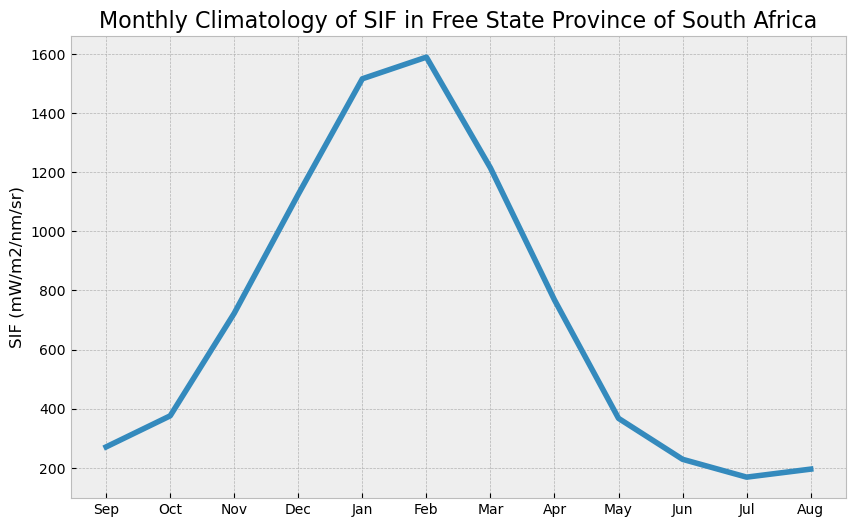

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
axes.plot(sif_monthly_clim.reindex(month=[9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]).values, lw=4)
axes.set_xticks(range(12))
axes.set_xticklabels(['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug'])
axes.set_ylabel('SIF (mW/m2/nm/sr)')
axes.set_title('Monthly Climatology of SIF in Free State Province of South Africa', fontsize=16)

In [26]:
sif_mask_agg = sif_mask.sum(dim=['lat', 'lon'])

In [9]:
crop_data = pd.read_csv('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/Harvest_stat/hvstat_africa_data_v1.0_20250212.csv')

In [12]:
crop_data_admin = crop_data[crop_data['admin_1']=='Free State']

In [21]:
crop_data_admin[crop_data_admin['product']=='Maize'][['harvest_year', 'production']]

,harvest_year,production
175597,1987,1477000.0
175598,1988,1440000.0
175599,1989,2235000.0
175600,1990,1588000.0
175601,1991,1170000.0
175602,1992,555000.0
175603,1993,1967000.0
175604,1994,2186000.0
175605,1995,710000.0
175606,1996,2232000.0


# Conservative-like remap without xESMF (area-weighted average via rasterio/rioxarray)
import numpy as np
import xarray as xr
import rioxarray  # noqa: F401 (needed to activate the .rio accessor)
from rasterio.enums import Resampling

# Start from high-resolution crop fraction
crop_hi = crop_mask_tif_xr.copy().rename('crop_fraction').astype('float32')

# Convert percentage to fraction if needed
if float(crop_hi.max()) > 1.0:
    crop_hi = crop_hi / 100.0

# Clean and constrain
crop_hi = crop_hi.where(np.isfinite(crop_hi)).clip(0.0, 1.0)

# Match longitude convention to SIF grid (0..360 vs -180..180)
sif_lon = sif_rt['lon']
if crop_hi['lon'].max() > 180 and sif_lon.min() < 0:
    crop_hi = crop_hi.assign_coords(lon=(((crop_hi['lon'] + 180) % 360) - 180))
elif crop_hi['lon'].min() < 0 and sif_lon.max() > 180:
    crop_hi = crop_hi.assign_coords(lon=(crop_hi['lon'] % 360))

# Ensure monotonic coordinates for reprojection
crop_hi = crop_hi.sortby('lat').sortby('lon')

# Build a target template exactly on the SIF grid
template = xr.DataArray(
    np.zeros((sif_rt.sizes['lat'], sif_rt.sizes['lon']), dtype='float32'),
    coords={'lat': sif_rt['lat'].values, 'lon': sif_rt['lon'].values},
    dims=('lat', 'lon'),
    name='template'
).sortby('lat').sortby('lon')

# Attach geospatial metadata and reproject-match using average resampling
crop_hi_geo = crop_hi.rio.set_spatial_dims(x_dim='lon', y_dim='lat').rio.write_crs('EPSG:4326')
template_geo = template.rio.set_spatial_dims(x_dim='lon', y_dim='lat').rio.write_crs('EPSG:4326')

crop_on_sif = crop_hi_geo.rio.reproject_match(
    template_geo,
    resampling=Resampling.average
).rename('crop_fraction')

# Keep valid range
crop_on_sif = crop_on_sif.clip(0.0, 1.0)

# Example hard and soft masks
crop_mask_hard = crop_on_sif >= 0.10  # keep cells with >=10% cropland
sif_crop_only = sif_rt['SIF_740_daily_corr'].where(crop_mask_hard)
sif_crop_weighted = sif_rt['SIF_740_daily_corr'] * crop_on_sif

print(crop_on_sif)